# Лабораторна робота №2
Мета роботи: 
Ознайомитися з принципами побудови асоціативних правил на реальних даних користувацьких уподобань.  
Навчитися виконувати пошук частих наборів елементів і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small.

Виконала: Брильова Дар'я КН-43

In [1]:
!pip install mlxtend

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_columns", 20)

In [3]:
#1b
ratings = pd.read_csv("ml-latest-small/ratings.csv")
movies = pd.read_csv("ml-latest-small/movies.csv")

print("Розмір ratings:", ratings.shape)
print("Розмір movies:", movies.shape)

ratings.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ml-latest-small/ratings.csv'

In [ ]:
#1c
df = ratings.merge(movies, on="movieId")

print("Розмір об'єднаної таблиці:", df.shape)

df.head()

Розмір об'єднаної таблиці: (100836, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
#1d-e
liked = df[df["rating"] >= 4.0].copy()

print("Розмір таблиці після фільтрації:", liked.shape)
print("Кількість унікальних користувачів:", liked["userId"].nunique())
print("Кількість унікальних фільмів:", liked["title"].nunique())

liked.head()

Розмір таблиці після фільтрації: (48580, 6)
Кількість унікальних користувачів: 609
Кількість унікальних фільмів: 6297


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
df[df["userId"] == 442].sort_values("rating")

,userId,movieId,rating,timestamp,title,genres
68324,442,1272,0.5,1331560460,Patton (1970),Drama|War
68332,442,3386,0.5,1331560586,JFK (1991),Drama|Mystery|Thriller
68328,442,2881,0.5,1331560518,Double Jeopardy (1999),Action|Crime|Drama|Thriller
68325,442,1644,0.5,1331560575,I Know What You Did Last Summer (1997),Horror|Mystery|Thriller
68330,442,3107,0.5,1331560477,Backdraft (1991),Action|Drama
68335,442,3863,0.5,1331560522,"Cell, The (2000)",Drama|Horror|Thriller
68322,442,1186,1.0,1331560556,"Sex, Lies, and Videotape (1989)",Drama
68320,442,610,1.0,1331560545,Heavy Metal (1981),Action|Adventure|Animation|Horror|Sci-Fi
68326,442,2020,1.0,1331560570,Dangerous Liaisons (1988),Drama|Romance
68323,442,1231,1.0,1331560577,"Right Stuff, The (1983)",Drama


Користувач 442 не увійшов у нашу вибірку тому що немає жодної оцінки >=4, тому кількість унікальних користувачів змінилась

In [ ]:
#2ab рядки - користувачі, стовпці - фільми, 1 якщо 4>= 
basket = (
    liked.assign(value=1)
    .pivot_table(index="userId", columns="title", values="value", fill_value=0)
)

basket = basket.astype(bool)

print("Розмір транзакційної матриці:", basket.shape)
basket.head()

Розмір транзакційної матриці: (609, 6297)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#3a-b
support_values = [0.05, 0.1, 0.3]

for s in support_values:
    frequent_temp = apriori(basket, min_support=s, use_colnames=True)
    print(f"min_support = {s}: кількість частих наборів = {len(frequent_temp)}")

min_support = 0.05: кількість частих наборів = 33189
min_support = 0.1: кількість частих наборів = 863
min_support = 0.3: кількість частих наборів = 6


In [ ]:
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print("Кількість знайдених частих наборів:", len(frequent_itemsets))
frequent_itemsets.head()

Кількість знайдених частих наборів: 33189


,support,itemsets,length
0,0.080460,frozenset({12 Angry Men (1957)}),1
1,0.124795,frozenset({2001: A Space Odyssey (1968)}),1
2,0.065681,frozenset({28 Days Later (2002)}),1
3,0.062397,frozenset({300 (2007)}),1
4,0.057471,"frozenset({40-Year-Old Virgin, The (2005)})",1


In [ ]:
#3c
top_itemsets = frequent_itemsets.sort_values(by="support", ascending=False).head(10)
top_itemsets

,support,itemsets,length
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})",1
119,0.408867,frozenset({Forrest Gump (1994)}),1
244,0.400657,frozenset({Pulp Fiction (1994)}),1
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})",1
206,0.364532,"frozenset({Matrix, The (1999)})",1
299,0.330049,frozenset({Star Wars: Episode IV - A New Hope (1977)}),1
115,0.293924,frozenset({Fight Club (1999)}),1
260,0.287356,frozenset({Schindler's List (1993)}),1
2228,0.275862,"frozenset({Forrest Gump (1994), Shawshank Redemption, The (1994)})",2
300,0.275862,frozenset({Star Wars: Episode V - The Empire Strikes Back (1980)}),1


In [ ]:
#3d (набори по два фільми які найчастіше зустрічаються(топ 10))
frequent_itemsets_2plus = frequent_itemsets[frequent_itemsets["length"] >= 2] \
    .sort_values(by="support", ascending=False)

frequent_itemsets_2plus.head(10)

,support,itemsets,length
2228,0.275862,"frozenset({Forrest Gump (1994), Shawshank Redemption, The (1994)})",2
3607,0.259442,"frozenset({Shawshank Redemption, The (1994), Pulp Fiction (1994)})",2
3610,0.249589,"frozenset({Pulp Fiction (1994), Silence of the Lambs, The (1991)})",2
3965,0.236453,"frozenset({Star Wars: Episode V - The Empire Strikes Back (1980), Star Wars: Episode IV - A New ...",2
3823,0.229885,"frozenset({Shawshank Redemption, The (1994), Silence of the Lambs, The (1991)})",2
2218,0.223317,"frozenset({Forrest Gump (1994), Pulp Fiction (1994)})",2
3768,0.211823,"frozenset({Schindler's List (1993), Shawshank Redemption, The (1994)})",2
2231,0.210181,"frozenset({Forrest Gump (1994), Silence of the Lambs, The (1991)})",2
3260,0.208539,"frozenset({Matrix, The (1999), Pulp Fiction (1994)})",2
3966,0.206897,"frozenset({Star Wars: Episode VI - Return of the Jedi (1983), Star Wars: Episode IV - A New Hope...",2


In [ ]:
#4a
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

print("Кількість знайдених правил:", len(rules))
rules.head()

Кількість знайдених правил: 360465


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({12 Angry Men (1957)}),frozenset({Fargo (1996)}),0.080460,0.224959,0.050903,0.632653,2.812304,1.0,0.032803,2.109834,0.700806,0.200000,0.526029,0.429465
1,frozenset({12 Angry Men (1957)}),frozenset({Pulp Fiction (1994)}),0.080460,0.400657,0.052545,0.653061,1.629977,1.0,0.020308,1.727519,0.420313,0.122605,0.421135,0.392104
2,frozenset({12 Angry Men (1957)}),frozenset({Schindler's List (1993)}),0.080460,0.287356,0.052545,0.653061,2.272653,1.0,0.029425,2.054091,0.608984,0.166667,0.513167,0.417959
3,frozenset({12 Angry Men (1957)}),"frozenset({Shawshank Redemption, The (1994)})",0.080460,0.449918,0.064039,0.795918,1.769030,1.0,0.027839,2.695402,0.472756,0.137324,0.628998,0.469127
4,frozenset({2001: A Space Odyssey (1968)}),frozenset({Alien (1979)}),0.124795,0.180624,0.072250,0.578947,3.205263,1.0,0.049709,1.946018,0.786116,0.309859,0.486130,0.489474


In [ ]:
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
0,frozenset({12 Angry Men (1957)}),frozenset({Fargo (1996)}),0.050903,0.632653,2.812304
1,frozenset({12 Angry Men (1957)}),frozenset({Pulp Fiction (1994)}),0.052545,0.653061,1.629977
2,frozenset({12 Angry Men (1957)}),frozenset({Schindler's List (1993)}),0.052545,0.653061,2.272653
3,frozenset({12 Angry Men (1957)}),"frozenset({Shawshank Redemption, The (1994)})",0.064039,0.795918,1.769030
4,frozenset({2001: A Space Odyssey (1968)}),frozenset({Alien (1979)}),0.072250,0.578947,3.205263
5,frozenset({Alien (1979)}),frozenset({2001: A Space Odyssey (1968)}),0.072250,0.400000,3.205263
6,frozenset({2001: A Space Odyssey (1968)}),frozenset({Aliens (1986)}),0.057471,0.460526,3.299536
7,frozenset({Aliens (1986)}),frozenset({2001: A Space Odyssey (1968)}),0.057471,0.411765,3.299536
8,frozenset({2001: A Space Odyssey (1968)}),frozenset({American Beauty (1999)}),0.062397,0.500000,2.003289
9,frozenset({Apocalypse Now (1979)}),frozenset({2001: A Space Odyssey (1968)}),0.064039,0.487500,3.906414


In [ ]:
rules_readable = rules.copy()

rules_readable["antecedents"] = rules_readable["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_readable["consequents"] = rules_readable["consequents"].apply(lambda x: ", ".join(list(x)))

rules_readable = rules_readable.sort_values(by="lift", ascending=False)

rules_readable[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
345913,"Star Wars: Episode V - The Empire Strikes Back (1980), Star Wars: Episode IV - A New Hope (1977)...","Matrix, The (1999), Kill Bill: Vol. 2 (2004), Star Wars: Episode VI - Return of the Jedi (1983)",0.052545,0.780488,13.203252
345903,"Matrix, The (1999), Kill Bill: Vol. 2 (2004), Star Wars: Episode VI - Return of the Jedi (1983)","Star Wars: Episode V - The Empire Strikes Back (1980), Star Wars: Episode IV - A New Hope (1977)...",0.052545,0.888889,13.203252
345896,"Matrix, The (1999), Star Wars: Episode V - The Empire Strikes Back (1980), Star Wars: Episode IV...","Kill Bill: Vol. 2 (2004), Star Wars: Episode VI - Return of the Jedi (1983)",0.052545,0.864865,12.846407
345918,"Star Wars: Episode VI - Return of the Jedi (1983), Kill Bill: Vol. 1 (2003)","Matrix, The (1999), Kill Bill: Vol. 2 (2004), Star Wars: Episode V - The Empire Strikes Back (19...",0.052545,0.780488,12.846407
345898,"Matrix, The (1999), Kill Bill: Vol. 2 (2004), Star Wars: Episode V - The Empire Strikes Back (19...","Star Wars: Episode VI - Return of the Jedi (1983), Kill Bill: Vol. 1 (2003)",0.052545,0.864865,12.846407
345920,"Kill Bill: Vol. 2 (2004), Star Wars: Episode VI - Return of the Jedi (1983)","Matrix, The (1999), Star Wars: Episode V - The Empire Strikes Back (1980), Star Wars: Episode IV...",0.052545,0.780488,12.846407
345890,"Matrix, The (1999), Kill Bill: Vol. 2 (2004), Star Wars: Episode VI - Return of the Jedi (1983),...","Star Wars: Episode V - The Empire Strikes Back (1980), Kill Bill: Vol. 1 (2003)",0.052545,0.969697,12.837945
345924,"Star Wars: Episode V - The Empire Strikes Back (1980), Kill Bill: Vol. 1 (2003)","Matrix, The (1999), Kill Bill: Vol. 2 (2004), Star Wars: Episode VI - Return of the Jedi (1983),...",0.052545,0.695652,12.837945
345915,"Matrix, The (1999), Kill Bill: Vol. 2 (2004), Star Wars: Episode V - The Empire Strikes Back (1980)","Star Wars: Episode VI - Return of the Jedi (1983), Star Wars: Episode IV - A New Hope (1977), Ki...",0.052545,0.800000,12.821053
345914,"Matrix, The (1999), Kill Bill: Vol. 2 (2004), Star Wars: Episode IV - A New Hope (1977)","Star Wars: Episode V - The Empire Strikes Back (1980), Star Wars: Episode VI - Return of the Jed...",0.052545,0.842105,12.821053


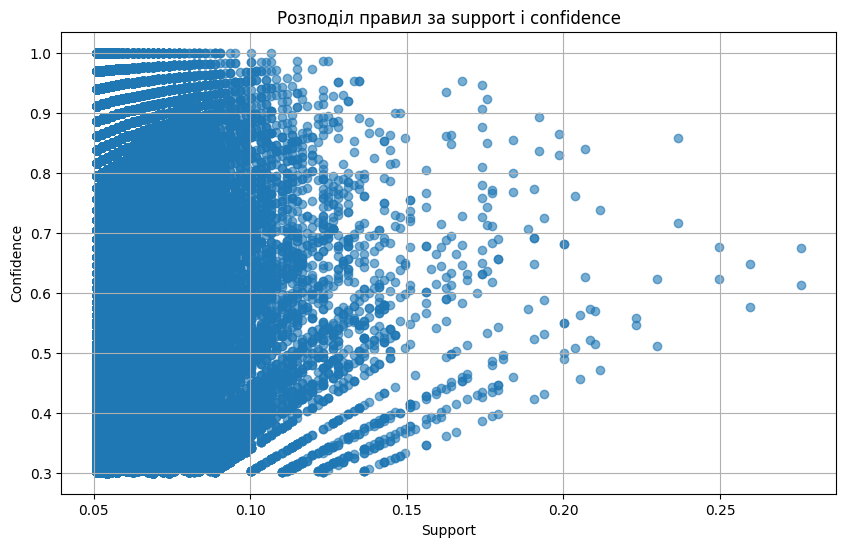

In [ ]:
plt.scatter(rules["support"], rules["confidence"], alpha=0.6)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Розподіл правил за support і confidence")
plt.grid(True)
plt.show()

На діаграмі розсіювання зображено розподіл асоціативних правил за метриками `support` і `confidence`. Кожна точка відповідає окремому правилу.

З графіка видно, що найбільша кількість правил зосереджена в області невеликих значень `support`, переважно від 0.05 до 0.10. Це свідчить про те, що більшість знайдених правил виконуються лише для частини користувачів, але все ж залишаються достатньо частими для включення в аналіз.

Значення `confidence` змінюються у широкому діапазоні — приблизно від 0.3 до 1.0. Отже, серед побудованих правил є як помірно надійні, так і дуже сильні правила. Також можна помітити, що деякі правила мають високий рівень `confidence`, але порівняно невеликий `support`, тобто вони є точними, проте характерними лише для обмеженої групи користувачів.

Таким чином, графік показує, що в наборі даних переважають правила з невисокою підтримкою, але серед них присутня значна кількість правил із високою достовірністю.


## Висновки

#### Застосування асоціативних правил у системах рекомендацій

Асоціативні правила можна ефективно використовувати в рекомендаційних системах для виявлення прихованих зв’язків між об’єктами, які подобаються користувачам. У даній роботі такими об’єктами є фільми, які користувачі оцінили позитивно. Якщо в даних часто зустрічається правило виду: якщо користувачеві сподобався фільм A, то йому також подобається фільм B, то це правило можна використати для формування рекомендацій.

Такий підхід дає змогу будувати рекомендації на основі реальної поведінки великої кількості користувачів. Наприклад, якщо новий користувач високо оцінив один фільм, система може запропонувати йому інші фільми, які часто пов’язані з ним у знайдених асоціативних правилах. Це особливо корисно для задач персоналізації, коли потрібно швидко сформувати список релевантних об’єктів без складного моделювання профілю користувача.

Перевагою асоціативних правил є їх інтерпретованість. На відміну від деяких інших методів рекомендацій, тут можна чітко пояснити, чому саме система пропонує той чи інший об’єкт: рекомендація базується на виявленому статистичному зв’язку між елементами. Отже, асоціативні правила є зручним інструментом для побудови простих і зрозумілих рекомендаційних механізмів.

#### Вплив параметрів min_support і min_confidence на кількість і якість правил

Параметр min_support визначає мінімальну частку транзакцій, у яких повинен зустрічатися набір елементів, щоб він вважався частим. Якщо значення min_support зменшувати, алгоритм знаходить більше частих наборів і, відповідно, більше асоціативних правил. Проте серед них з’являється багато правил, які характерні лише для невеликої частини користувачів, тобто є менш універсальними. Якщо ж min_support збільшувати, кількість знайдених наборів та правил зменшується, але залишаються лише найбільш поширені та стійкі закономірності.

Параметр min_confidence задає мінімально допустимий рівень достовірності правила. При малих значеннях min_confidence правил буде більше, але серед них буде багато слабших, де залежність між лівою і правою частинами виражена недостатньо чітко. При збільшенні min_confidence кількість правил зменшується, зате самі правила стають більш надійними, оскільки ймовірність виконання правої частини за наявності лівої є вищою.

Отже, параметри min_support і min_confidence безпосередньо впливають як на кількість, так і на якість знайдених правил. Малі значення цих параметрів дають більше результатів, але частина з них може бути менш значущою або менш корисною на практиці. Великі значення, навпаки, відсіюють слабкі правила та залишають меншу кількість більш сильних і надійних закономірностей. Тому при побудові рекомендаційної системи важливо підбирати ці параметри так, щоб досягти балансу між повнотою результатів і їх практичною цінністю.